# MNIST Handwritten Digit Classification (PyTorch CNN)

## Assignment Questions (Follow in Order)

- **Q1 (15 pts):** Build the MNIST data pipeline (transforms, train/val split, DataLoaders).
- **Q2 (20 pts):** Implement a CNN classifier with the specified architecture.
- **Q3 (40 pts):** Implement training and validation functions, run training loop with checkpointing, and plot curves.
  - 3.1 (15 pts): Training function
  - 3.2 (8 pts): Validation function
  - 3.3 (11 pts): Training loop with best checkpoint saving
  - 3.4 (6 pts): Plot training and validation curves
- **Q4 (5 pts):** Load the best checkpoint and evaluate on the test set.

**Total: 80 points**

---

## Starter Notebook (Student Version)

Fill in the sections marked with:

```python
# ========== YOUR CODE STARTS HERE ==========
# ========== YOUR CODE ENDS HERE ============
```

Do **not** change the rubric section above.

In [10]:
# If you are running in a fresh environment, uncomment to install dependencies:
!pip -q install torch torchvision matplotlib tqdm scikit-learn

import os
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

print("torch:", torch.__version__)
device = "cpu"  # For fixed, reproducible results. (You may switch to "cuda" after you finish debugging.)
print("device:", device)

def set_seed(seed: int = 42):
    """Make results as reproducible as possible across runs."""
    import os, random
    import numpy as np
    import torch

    os.environ["PYTHONHASHSEED"] = str(seed)
    # If you later switch to CUDA and want maximal determinism:
    # os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Deterministic flags (safe on CPU; on GPU some ops may error if non-deterministic)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception as e:
        print("Warning: could not enable full deterministic algorithms:", e)

set_seed(42)



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
torch: 2.12.0
device: cpu


## 1. Dataset and DataLoader (15 pts)

In [11]:
# Q1: Build the data pipeline
data_dir = "./data"
batch_size = 128  # Use 128 for training
num_workers = 0  # For fully reproducible ordering across platforms

# ========== YOUR CODE STARTS HERE ==========
# TODO:
# 1) Create transforms for train and test (normalize with mean=0.1307, std=0.3081)
#    Avoid random augmentation for reproducibility
# 2) Load MNIST datasets (train and test) using datasets.MNIST()
# 3) Split training set into train (55k) and validation (5k) using random_split
# 4) Create three DataLoaders (train, val, test)
#    For train_loader, use shuffle=True

# Student's notes:
# https://docs.pytorch.org/vision/stable/transforms.html
# https://docs.pytorch.org/vision/stable/auto_examples/transforms/plot_transforms_getting_started.html#sphx-glr-auto-examples-transforms-plot-transforms-getting-started-py
#   torchvision.transforms docs:
#   transforms.Compose - Chains multiple transforms together into one pipeline
#   transforms.Normalize - Standardizes each pixel value - output = (input - mean)
#      / std.
#   Therefore, a dataset average pixel value becomes 0.0 after normalization, 
#      centering the data around zero, helping the network train faster/stably.
# Tuples are 1-element tuples because MNIST is grayscale (1 channel instead 
#      of 3 in RGB).

# Student's conceptual notes:
# PyTorch uses its own torch.Tensor type instead of NumPy arrays (can track
#   gradients automatically for backprop).
# Why normalize? Gradient stability. NN weights are initialized near zero. If 
#   inputs start of sprasely, the gradients flowing back can be very large
#   or very small depending on scale, making training slow or unstable. 
#   Also, equal footing across features. For images it matters less (all pixels 
#   are on the same scale already?) but normalization ensures no pixel is 
#   systematically "louder" than others just due to brightness offset. The mean
#   of average pixel brightness becomes 0 (subtracting it removes that bias).

# torchvision.datasets.MINST
# https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html

# torch.utils.data.random_split (55k / 5k split)
# random_split(full_train, [55000, 5000])
# "Randomly split a dataset into non-overlapping new datasets of given lengths."
# https://pytorch.org/docs/stable/data.html#torch.utils.data.random_split

# torch.utils.data.DataLoader
# https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader

# from torchvision.transforms import v2
# Professor already imported entire transforms module, so everything
# inside it is accessed with dot notation - transforms.ToTensor(), not
# v2.ToTensor() like docs.
# Assignment expects v1, not v2. Try v2 later for experimental fun.

train_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # Professor provided mean and std
])

test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # Professor provided mean and std
])

full_train = datasets.MNIST(root=data_dir, train=True, download=True, transform=train_tf)
test_set = datasets.MNIST(root=data_dir, train=False, download=True, transform=test_tf)

train_set, val_set = random_split(full_train, [55000, 5000])

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=num_workers)
# ========== YOUR CODE ENDS HERE ============

print("train/val/test:", len(train_set), len(val_set), len(test_set))

train/val/test: 55000 5000 10000


## 2. Define the CNN Model (20 pts)

In [12]:
# Q2: Define your CNN model
class MNISTCNN(nn.Module):
    """Input: (B,1,28,28) -> Output: (B,10)"""
    def __init__(self, num_classes=10):
        super().__init__()
        # ========== YOUR CODE STARTS HERE ==========
        # Build a CNN with:
        # - Feature extraction: 3 convolutional blocks
        #   * First block: 1 input channel to 32 output channels, with BatchNorm and ReLU, then MaxPool
        #   * Second block: 32 to 64 channels, with BatchNorm and ReLU, then MaxPool
        #   * Third block: 64 to 128 channels, with ReLU (no pooling)
        #   Use kernel_size=3 and padding=1 for all convolutions, pool_size=2 for pooling
        # - Classifier: Flatten, then fully connected layers
        #   * After two MaxPool layers, your feature map will be 7x7
        #   * First FC layer: 128*7*7 inputs to 256 outputs, with ReLU and Dropout(0.3)
        #   * Final FC layer: 256 to num_classes outputs

        # Student's notes:
        # Convolution layer, nn.Conv2d
        # https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
        #   Instead of connecting every pixel to every neuron whihc is expensive,
        #   a conv layer slides a small filter (kernel) across the image and
        #   looks for local patterns like edges, curves, and textures. Each
        #   filter produces one output "channel."
        #   Conv2d(1, 32, 3, 1) -> takes 1 grayscale channel, learns 32 diff filters
        #
        # Batch Normalization, nn.BatchNorm2d
        # https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html
        #   Normalizes output of a layer across each batch during training, like
        #   normalizing your inputs, but applied between layers too. Keeps values
        #   well-behaved as they flow deeper into the network, which stabilizes
        #   and speeds up training.
        #
        # ReLu, nn.ReLU - activation function, non-linearity. Output = max(0, x)
        #
        # MaxPool, nn.MaxPool2d
        # https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html
        #    Downsamples spatial dimensions by taking maximum value in each window.
        #    With pool size 2, a 28x28 feature map becomes 14x14. Two MaxPool
        #    layers: 28->14->7, which is why classifier sees 7x7.
        #
        # Dropout, nn.Dropout
        # https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html
        #    During training, randomly zeroes out a fraction of neurons. Forces
        #    network not to rely too heavily on any one neuron. Reduces overfitting.
        #
        # nn.Sequential chains layers in order
        
        self.features = nn.Sequential(
            # Block #1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block #2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block #3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.3), # 30%
            nn.Linear(256, num_classes),
        )
        
        # ========== YOUR CODE ENDS HERE ============

    def forward(self, x):
        # ========== YOUR CODE STARTS HERE ==========
        # Pass input through features, then classifier
        x = self.features(x)
        x = self.classifier(x)
        return x
        # ========== YOUR CODE ENDS HERE ============

model = MNISTCNN().to(device)
print(model)

# Parameter count
num_params = sum(p.numel() for p in model.parameters())
print("Total params:", num_params)

MNISTCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)
Total params: 1701322


## 3. Training Loop (40 pts)

### 3.1 Training Function (15 pts)

In [13]:
# Q3.1: Training function
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, loader):
    """Train for one epoch and return (avg_loss, accuracy)."""
    # ========== YOUR CODE STARTS HERE ==========
    # TODO:
    # - Set model to training mode
    # - Loop through batches in the loader
    # - For each batch: 
    #   * Zero gradients
    #   * Forward pass
    #   * Compute loss
    #   * Backward pass
    #   * Optimizer step
    # - Track total loss and accuracy (IMPORTANT: get predicted labels and compare with targets)
    # - Return average loss and accuracy

    # Student's notes
    # model.train() (puts model in training mode)
    # https://pytorch.org/docs/stable/generated/torch.nn.Module.train.html
    #
    # optimizer.zero_grad() (PyTorch accumulates gradients by default. You
    #    zero them out at start of each batch so gradients don't carry over
    #    from the last batch.
    # https://pytorch.org/docs/stable/optim.html
    #
    # Forward pass, loss, backward pass
    # outputs = model(inputs) - forward pass, get predictions
    # loss = criterion(outputs, targets) - compute how wrong we are
    #    nn.CrossEntropyLoss()
    # loss.backward() - backprop, compute gradients
    # optimizer.step() - update weights using those gradients
    #
    # Accuracy tracking
    # outputs is shape (batch_size, 10). One score per class. To get predicted
    # class, take index of highest score.
    # preds = outputs.argmax(dim=1)
    # correct = (preds == targets).sum().item()
    
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == targets).sum().item()
        total_samples += inputs.size(0)

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return avg_loss, accuracy
    # ========== YOUR CODE ENDS HERE ============

### 3.2 Validation Function (8 pts)

In [14]:
# Q3.2: Validation function
@torch.no_grad()
def evaluate(model, loader):
    """Evaluate model and return (avg_loss, accuracy)."""
    # ========== YOUR CODE STARTS HERE ==========
    # TODO:
    # - Set model to evaluation mode
    # - Loop through batches without computing gradients
    # - Compute loss and accuracy
    # - Return average loss and accuracy

    # Student's notes
    # model.eval() - evaluation mode, instead of training mode. Disables Dropout.
    #   BatchNorm uses running stats instead of batch stats.
    # torch.no_grad() - disables gradient computation since we aren't updating
    #   weights, saves memory and speeds things up
    # ^ @torch.no_grad() decorator is already in the function ;)
    # 
    # Loop through batches, compute loss and accuracy, just no zero_grad, backward,
    # or optimizer.step, or else it's same as 3.1

    model.eval() # Leave training mode, enter eval mode
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        total_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == targets).sum().item()
        total_samples += inputs.size(0)

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    
    return avg_loss, accuracy
    # ========== YOUR CODE ENDS HERE ============

### 3.3 Training Loop (11 pts)

In [15]:
# Q3.3: Training loop with checkpointing
epochs = 10
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_epoch = -1
ckpt_path = "./checkpoints/best_mnist_cnn.pt"
os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)

# ========== YOUR CODE STARTS HERE ==========
# TODO:
# - Loop through epochs
# - Each epoch: train, validate, log metrics
# - Track best validation accuracy and save checkpoint when improved
# - Print training and validation metrics each epoch
# - For checkpoint: save a dictionary containing keys `model_state_dict` and `epoch`

# Student's notes:
# torch.save / torch.load - actually saves and loads Python objects to disk
# model.state_dict() returns all the learned weights as a dictionary
#
# https://pytorch.org/docs/stable/generated/torch.save.html

for epoch in range(epochs):
      train_loss, train_acc = train_one_epoch(model, train_loader)
      val_loss, val_acc = evaluate(model, val_loader)
      
      history["train_loss"].append(train_loss)
      history["train_acc"].append(train_acc)
      history["val_loss"].append(val_loss)
      history["val_acc"].append(val_acc)
      
      if val_acc > best_val_acc:
          best_val_acc = val_acc
          best_epoch = epoch
          torch.save({"model_state_dict": model.state_dict(), "epoch": epoch}, ckpt_path)
          
      print(f"Epoch {epoch+1}/{epochs} | train loss: {train_loss:.4f} | train acc: {train_acc:.4f} | val loss: {val_loss:.4f} | val acc: {val_acc:.4f}")

# ========== YOUR CODE ENDS HERE ============

print("Best val acc:", best_val_acc, "at epoch", best_epoch)
print("Saved to:", ckpt_path)

Epoch 1/10 | train loss: 0.1234 | train acc: 0.9616 | val loss: 0.0482 | val acc: 0.9838
Epoch 2/10 | train loss: 0.0439 | train acc: 0.9866 | val loss: 0.0428 | val acc: 0.9876
Epoch 3/10 | train loss: 0.0327 | train acc: 0.9896 | val loss: 0.0352 | val acc: 0.9880
Epoch 4/10 | train loss: 0.0244 | train acc: 0.9921 | val loss: 0.0290 | val acc: 0.9900
Epoch 5/10 | train loss: 0.0204 | train acc: 0.9934 | val loss: 0.0297 | val acc: 0.9896
Epoch 6/10 | train loss: 0.0184 | train acc: 0.9940 | val loss: 0.0560 | val acc: 0.9858
Epoch 7/10 | train loss: 0.0155 | train acc: 0.9952 | val loss: 0.0366 | val acc: 0.9916
Epoch 8/10 | train loss: 0.0140 | train acc: 0.9956 | val loss: 0.0308 | val acc: 0.9914
Epoch 9/10 | train loss: 0.0118 | train acc: 0.9961 | val loss: 0.0365 | val acc: 0.9906
Epoch 10/10 | train loss: 0.0120 | train acc: 0.9963 | val loss: 0.0522 | val acc: 0.9898
Best val acc: 0.9916 at epoch 6
Saved to: ./checkpoints/best_mnist_cnn.pt


### 3.4 Plot Training Curves (6 pts)

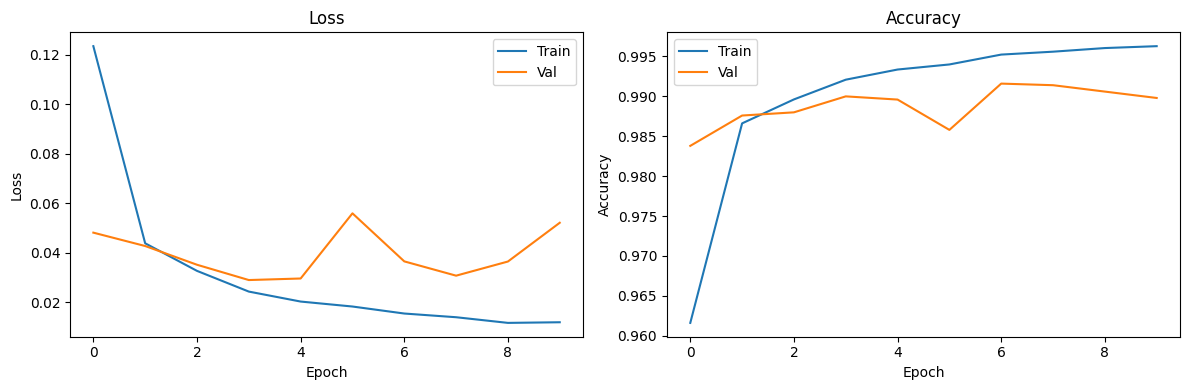

In [17]:
# Q3.4: Plot curves
# ========== YOUR CODE STARTS HERE ==========
# TODO:
# - Create two plots: one for loss (train vs val), one for accuracy (train vs val)
# - Use the history dictionary to get the values
# - Add labels, legends, and display the plots

# matplotlib
# - plt.subplots - creates the figures/axes
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html
# - ax.plot - draw line
# - https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html
# https://matplotlib.org/stable/tutorials/index.html
# matplotlib.org/stable/tutorials
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"], label="Val")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(history["train_acc"], label="Train")
ax2.plot(history["val_acc"], label="Val")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()

plt.tight_layout()
plt.show()

# ========== YOUR CODE ENDS HERE ============

## 4. Testing (5 pts)

In [19]:
# Q4: Test evaluation
# ========== YOUR CODE STARTS HERE ==========
# TODO:
# - Load the best checkpoint (it's a dictionary with 'model_state_dict' and 'epoch')
# - Load the model state from the checkpoint
# - Evaluate on the test set
# - Print test loss and accuracy

# Student's notes
# map_location=device ensures loads it onto CPU even if saved from GPU
# evaluate is from 3.2

checkpoint = torch.load(ckpt_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

test_loss, test_acc = evaluate(model, test_loader) 
# ========== YOUR CODE ENDS HERE ============

print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

Test loss: 0.0224 | Test acc: 0.9933
